In [13]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [14]:
path = "../data/"
features = path + "features.csv"

df = pd.read_csv(features)
df.describe()

,Unnamed: 0,Asymmetry,Border,HSV_Hue_Variance,HSV_Saturation_Variance,HSV_Value_Variance,Cancerous
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,249.500000,0.434030,0.741446,0.038319,0.005828,0.005041,0.500000
std,144.481833,0.419782,0.107390,0.113337,0.006266,0.006501,0.500501
min,0.000000,0.063465,-0.832000,0.000000,0.000000,0.000000,0.000000
25%,124.750000,0.179834,0.692000,0.000924,0.001774,0.001102,0.000000
50%,249.500000,0.272662,0.723000,0.002705,0.003846,0.002640,0.500000
75%,374.250000,0.460602,0.777000,0.011616,0.007502,0.006292,1.000000
max,499.000000,1.927139,0.994000,0.774569,0.058118,0.059041,1.000000


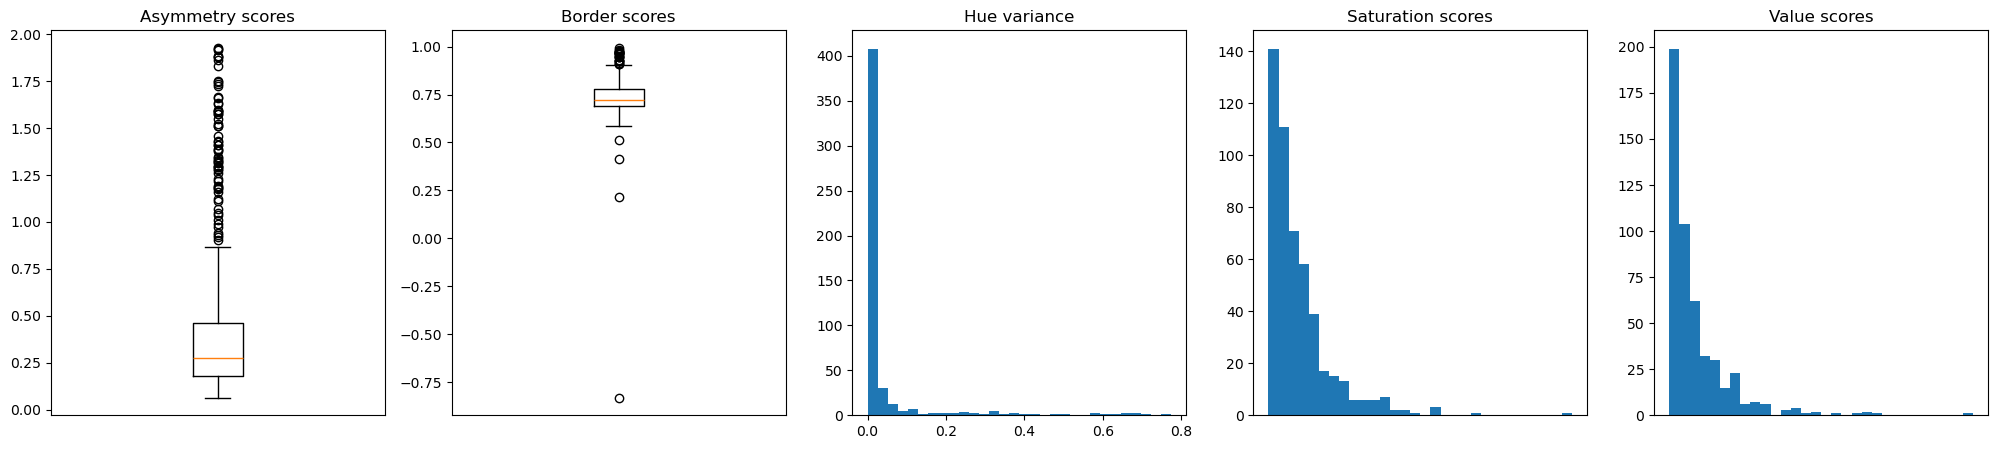

In [15]:
plt.figure(figsize=(25,5))
plt.subplot(1,5,1)
plt.boxplot(df["Asymmetry"])
plt.title("Asymmetry scores")
plt.xticks([])

plt.subplot(1,5,2)
plt.boxplot(df["Border"])
plt.title("Border scores")
plt.xticks([])

plt.subplot(1,5,3)
plt.hist(df["HSV_Hue_Variance"],bins=30)
plt.title("Hue variance")

plt.subplot(1,5,4)
plt.hist(df["HSV_Saturation_Variance"],bins=30)
plt.title("Saturation scores")
plt.xticks([])

plt.subplot(1,5,5)
plt.hist(df["HSV_Value_Variance"],bins=30)
plt.title("Value scores")
plt.xticks([])
plt.show()

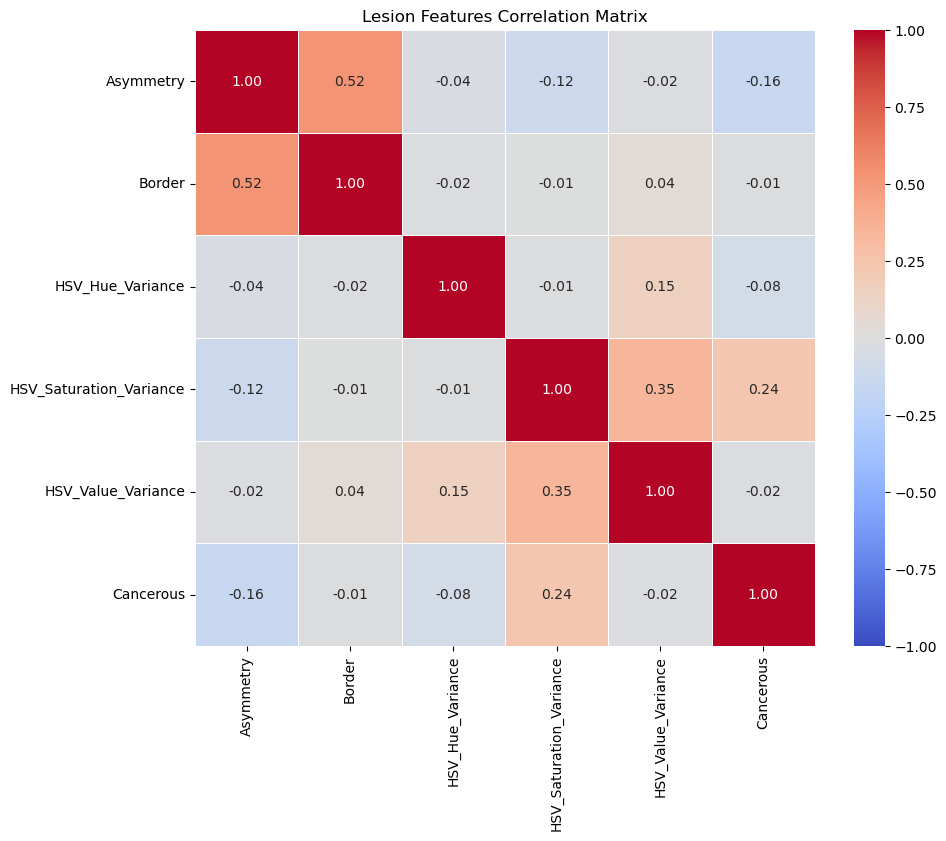

In [16]:
# Make the canvas a bit bigger
plt.figure(figsize=(10, 8))

# Drop the junk column (errors='ignore' just means it won't crash if you already dropped it)
df_clean = df.drop(columns=['Unnamed: 0'], errors='ignore')

# Draw the heatmap with the proper Data Science settings
sns.heatmap(data=df_clean.corr(numeric_only=True), 
            annot=True,         # Turns on the numbers!
            fmt=".2f",          # Rounds the numbers to 2 decimal places
            cmap="coolwarm",    # Uses a Blue-White-Red color scale
            vmin=-1,            # Locks the absolute minimum to -1
            vmax=1,             # Locks the absolute maximum to +1
            center=0,           # Forces exactly 0 to be neutral white
            linewidths=0.5)     # Adds a tiny grid line to separate boxes

plt.title("Lesion Features Correlation Matrix")
plt.show()

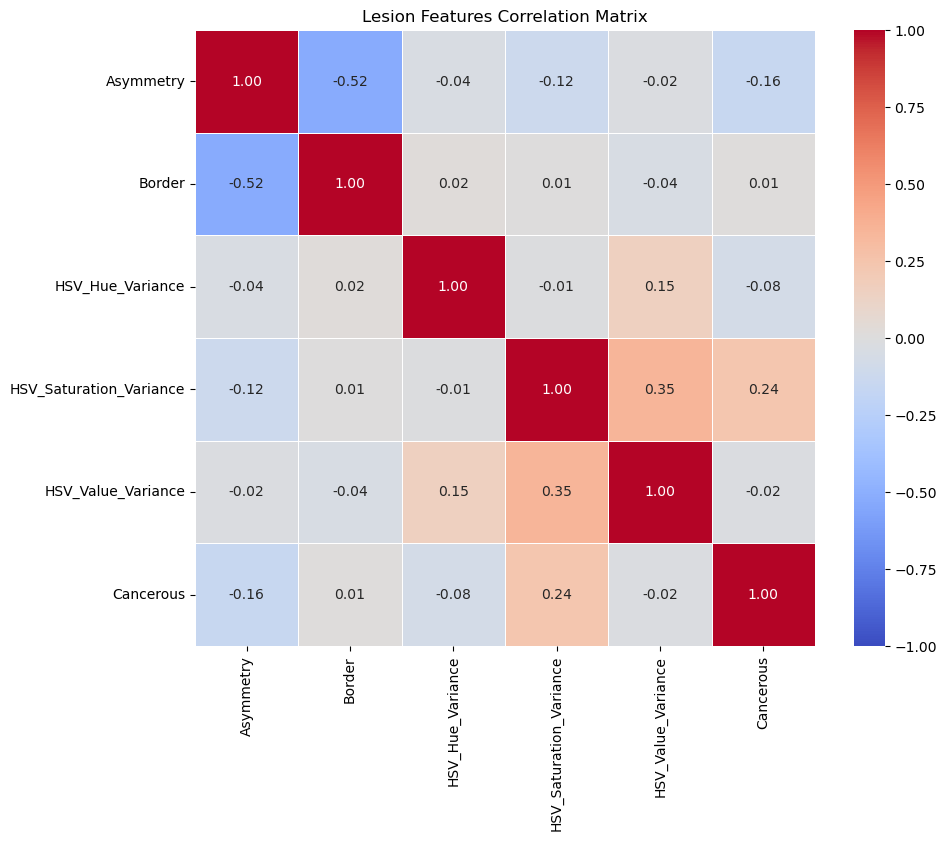

In [17]:
df_copy = df.copy()
df_copy["Border"] = 1 - df["Border"]
df_copy = df_copy.drop(columns=['Unnamed: 0'], errors='ignore')

plt.figure(figsize=(10, 8))
sns.heatmap(data=df_copy.corr(numeric_only=True), 
            annot=True,       
            fmt=".2f",         
            cmap="coolwarm", 
            vmin=-1,            
            vmax=1,             
            center=0,           
            linewidths=0.5)     

plt.title("Lesion Features Correlation Matrix")
plt.show()

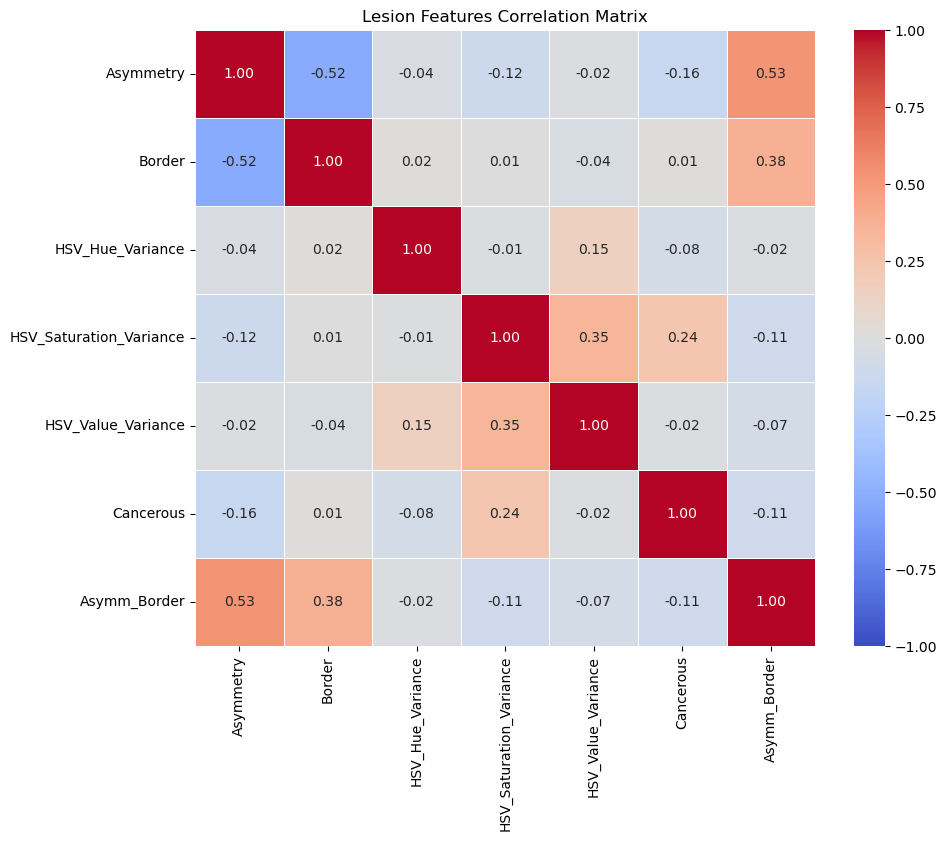

In [18]:
df_copy["Asymm_Border"] = df_copy["Asymmetry"]*df_copy["Border"]

plt.figure(figsize=(10, 8))
sns.heatmap(data=df_copy.corr(numeric_only=True), 
            annot=True,       
            fmt=".2f",         
            cmap="coolwarm", 
            vmin=-1,            
            vmax=1,             
            center=0,           
            linewidths=0.5)     

plt.title("Lesion Features Correlation Matrix")
plt.show()


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Prepare your Data
# ADDED 'ID' TO THE DROP LIST SO THE MODEL ONLY GETS NUMBERS
X = df.drop(columns=['Cancerous', 'Unnamed: 0', 'Asymm_Border', 'ID'], errors='ignore')
y = df['Cancerous']

# 2. Split into Train and Test (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# ==========================================
# MODEL 1: The Baseline (Logistic Regression)
# ==========================================
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced')
log_reg.fit(X_train, y_train)
log_preds = log_reg.predict(X_test)

print("--- LOGISTIC REGRESSION (BASELINE) ---")
print(f"Accuracy: {accuracy_score(y_test, log_preds):.3f}")
print(classification_report(y_test, log_preds))

# ==========================================
# MODEL 2: The Hero (Random Forest)
# ==========================================
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print("\n--- RANDOM FOREST ---")
print(f"Accuracy: {accuracy_score(y_test, rf_preds):.3f}")
print(classification_report(y_test, rf_preds))

--- LOGISTIC REGRESSION (BASELINE) ---
Accuracy: 0.610
              precision    recall  f1-score   support

           0       0.70      0.38      0.49        50
           1       0.58      0.84      0.68        50

    accuracy                           0.61       100
   macro avg       0.64      0.61      0.59       100
weighted avg       0.64      0.61      0.59       100


--- RANDOM FOREST ---
Accuracy: 0.640
              precision    recall  f1-score   support

           0       0.66      0.58      0.62        50
           1       0.62      0.70      0.66        50

    accuracy                           0.64       100
   macro avg       0.64      0.64      0.64       100
weighted avg       0.64      0.64      0.64       100



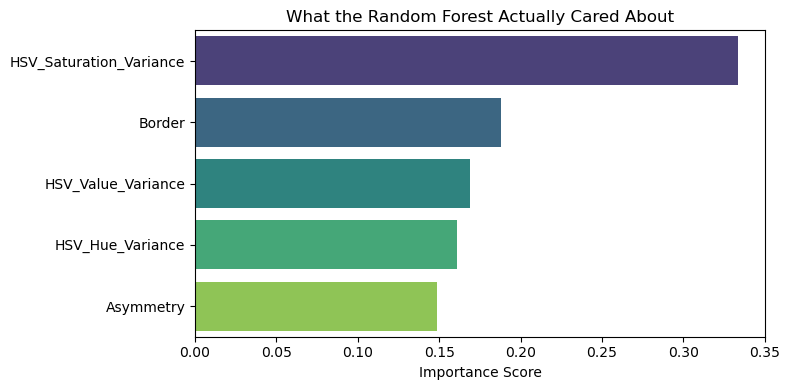

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extract the importance scores from the trained Random Forest
importances = rf_model.feature_importances_
feature_names = X_train.columns

# Put them in a DataFrame and sort them
df_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
df_imp = df_imp.sort_values(by='Importance', ascending=False)

# Plot it
plt.figure(figsize=(8, 4))
sns.barplot(data=df_imp, x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title("What the Random Forest Actually Cared About")
plt.xlabel("Importance Score")
plt.ylabel("")
plt.tight_layout()
plt.show()

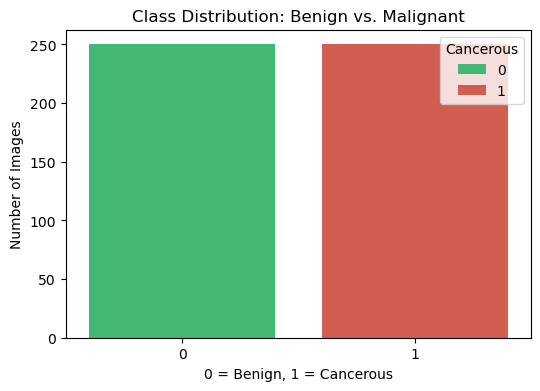

In [21]:
plt.figure(figsize=(6, 4))
# 'palette' makes the 0s green (healthy) and 1s red (danger)
sns.countplot(data=df, x='Cancerous',hue="Cancerous", palette=['#2ecc71', '#e74c3c'])
plt.title("Class Distribution: Benign vs. Malignant")
plt.xlabel("0 = Benign, 1 = Cancerous")
plt.ylabel("Number of Images")
plt.show()

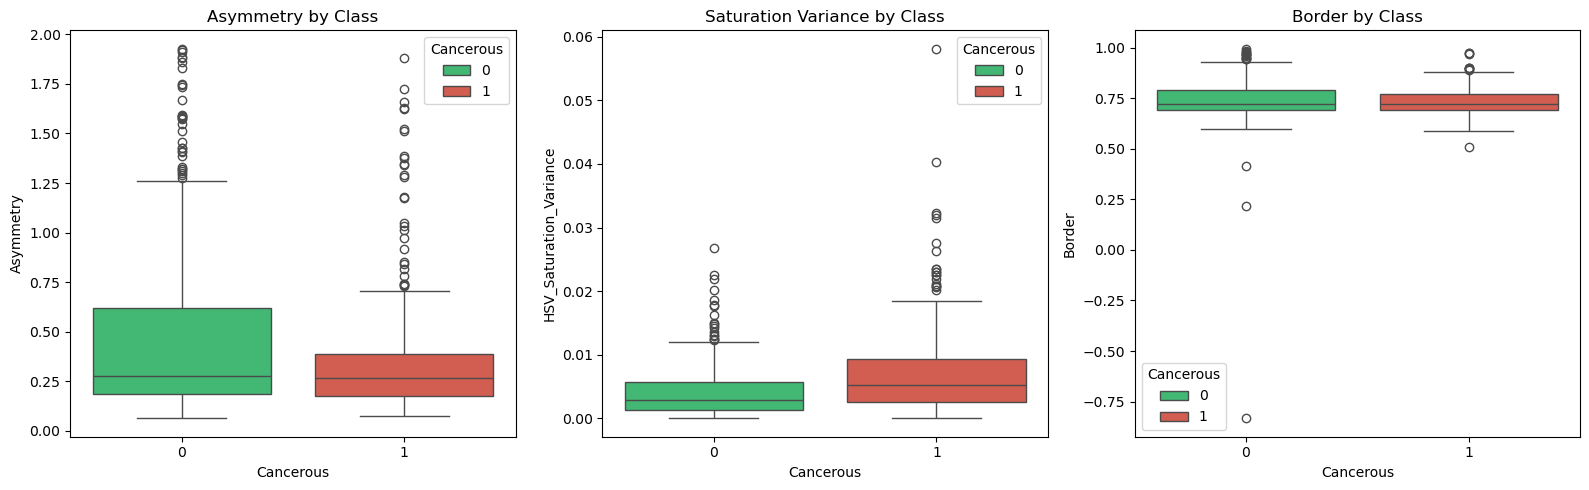

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Asymmetry
sns.boxplot(data=df, x='Cancerous', y='Asymmetry',hue="Cancerous", palette=['#2ecc71', '#e74c3c'], ax=axes[0])
axes[0].set_title("Asymmetry by Class")

# Plot 2: Saturation Variance
sns.boxplot(data=df, x='Cancerous', y='HSV_Saturation_Variance',hue="Cancerous", palette=['#2ecc71', '#e74c3c'], ax=axes[1])
axes[1].set_title("Saturation Variance by Class")

# Plot 3: Border
sns.boxplot(data=df, x='Cancerous', y='Border',hue="Cancerous", palette=['#2ecc71', '#e74c3c'], ax=axes[2])
axes[2].set_title("Border by Class")

plt.tight_layout()
plt.show()

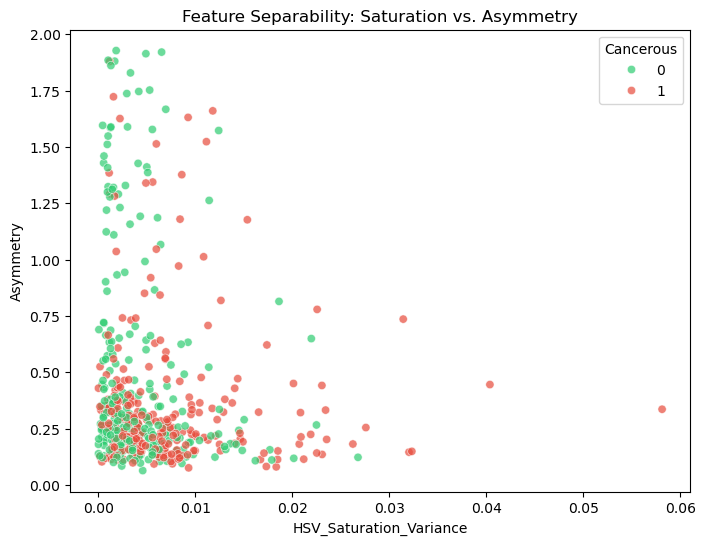

In [23]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, 
                x='HSV_Saturation_Variance', 
                y='Asymmetry', 
                hue='Cancerous', 
                palette=['#2ecc71', '#e74c3c'], 
                alpha=0.7) # alpha makes the dots slightly transparent so you can see overlaps

plt.title("Feature Separability: Saturation vs. Asymmetry")
plt.show()

In [24]:
df["Cancerous"].value_counts()

Cancerous
0    250
1    250
Name: count, dtype: int64